In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv("E:\electricity_random_dataset_200.csv")
df.head()

,Customer_ID,Units_Consumed,Rate_per_Unit,Electricity_Bill
0,CUST001,1091,9.0,9850.71
1,CUST002,265,6.0,1565.06
2,CUST003,1126,9.0,10154.82
3,CUST004,935,9.0,8369.23
4,CUST005,745,7.5,5619.57


In [4]:
df.isnull().sum()

Customer_ID         0
Units_Consumed      0
Rate_per_Unit       0
Electricity_Bill    0
dtype: int64

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Customer_ID       200 non-null    object 
 1   Units_Consumed    200 non-null    int64  
 2   Rate_per_Unit     200 non-null    float64
 3   Electricity_Bill  200 non-null    float64
dtypes: float64(2), int64(1), object(1)
memory usage: 6.4+ KB


In [6]:
df.describe()

,Units_Consumed,Rate_per_Unit,Electricity_Bill
count,200.000000,200.000000,200.000000
mean,630.870000,7.245000,5068.786600
std,332.141995,1.563553,3295.521695
min,45.000000,4.500000,158.030000
25%,345.250000,6.000000,2060.482500
50%,642.000000,7.500000,4820.915000
75%,920.750000,9.000000,8328.402500
max,1194.000000,9.000000,10766.110000


In [7]:
new_df=df[['Units_Consumed','Electricity_Bill']]
new_df.head()

,Units_Consumed,Electricity_Bill
0,1091,9850.71
1,265,1565.06
2,1126,10154.82
3,935,8369.23
4,745,5619.57


[]

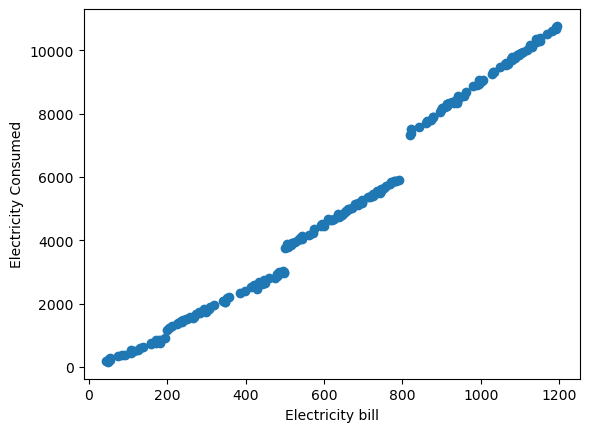

In [8]:
plt.scatter(new_df['Units_Consumed'],new_df['Electricity_Bill'])
plt.xlabel('Electricity bill')
plt.ylabel('Electricity Consumed')
plt.plot()


In [9]:
# spliting the data
X=new_df.iloc[:,:-1].values
y=new_df.iloc[:,-1].values

In [22]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=0,)

In [23]:
from sklearn.linear_model import LinearRegression

In [24]:
lr=LinearRegression()
lr.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [25]:
y_pred=lr.predict(X_test)
y_pred

array([ 4680.95816089,   -37.44475848,  3917.6871004 ,  6108.37417011,
         101.33179797,   755.56413553,  7506.05234581,  5473.9670549 ,
        8170.19729454,  9538.13763671,  8308.973851  ,  3570.74570927,
        6960.85873117, 10608.69964363,  1776.56308657,   537.48668967,
        5384.75355433,  -681.76448487,  4215.06543566,  4383.57982563,
        5920.03455778,  4512.44377091,  -741.24015192,  4968.42388497,
        4918.86082909,  9211.02146793,  3580.65832045,  -106.83303671,
        8140.45946102,  7862.90634811,  5731.69494546,  5008.07432967,
        -344.73570491, 10212.19519662, 10113.06908487,  6108.37417011,
        6643.65517357,  6197.58767069,  7525.87756816,  1865.77658715])

In [26]:
y_test

array([ 4481.55,   510.84,  3850.06,  5546.44,   597.21,   908.18,
        7894.86,  5008.72,  8499.11,  9738.66,  8556.9 ,  2855.72,
        7519.23, 10665.34,  1744.53,   778.93,  4981.04,   234.86,
        4123.56,  4170.24,  5375.45,  4368.49,   189.71,  4630.27,
        4646.36,  9464.43,  2859.55,   455.79,  8551.05,  8244.2 ,
        5222.6 ,  4684.58,   384.93, 10376.99, 10254.54,  5486.96,
        5910.02,  5619.57,  7893.6 ,  1828.07])

In [27]:
c=lr.coef_

In [28]:
i=lr.intercept_

In [29]:
265*c+i

array([1439.53430661])

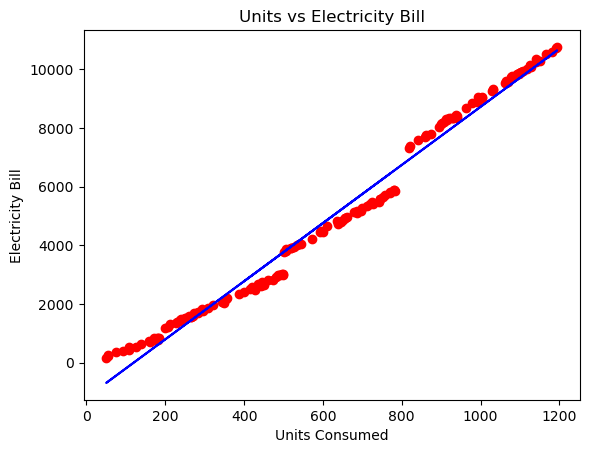

In [30]:
plt.scatter(X_train, y_train, color='red')      # Actual data
plt.plot(X_train, lr.predict(X_train), color='blue')   # Best fit line

plt.title("Units vs Electricity Bill")
plt.xlabel("Units Consumed")
plt.ylabel("Electricity Bill")
plt.show()

In [31]:
def predict_bill(units):
    
    prediction = lr.predict([[units]])
    
    return f"Estimated Electricity Bill: {prediction[0]:.2f}"

In [32]:
import gradio as gr

app = gr.Interface(
    
    fn=predict_bill,
    
    inputs=gr.Number(label="Enter Units Consumed"),
    
    outputs=gr.Textbox(label="$ Predicted Bill"),
    
    title="Electricity Bill Predictor",
    
    description="Enter electricity units to predict the bill"
)

app.launch()

* Running on local URL:  http://127.0.0.1:7861
* To create a public link, set `share=True` in `launch()`.


In [21]:
from gradio_client import Client

client = Client("http://127.0.0.1:7861")
result = client.predict(
	units=3,
	api_name="/predict_bill",
)
print(result)

Loaded as API: http://127.0.0.1:7861/


ConnectError: [WinError 10061] No connection could be made because the target machine actively refused it

# Multiple Linear Regression

In [1]:
import numpy as np
from sklearn.datasets import load_diabetes

In [4]:
X,y=load_diabetes(return_X_y=True)
X.shape
y.shape

(442,)

In [7]:
# linear regression using scikit -learn 
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=2)

In [8]:
print(X_train.shape)
print(X_test.shape)

(353, 10)
(89, 10)


In [9]:
from sklearn.linear_model import LinearRegression

In [10]:
reg=LinearRegression()

In [11]:
reg.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [12]:
y_pred=reg.predict(X_test)

In [14]:
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)

0.4399338661568968

In [15]:
reg.coef_

array([  -9.15865318, -205.45432163,  516.69374454,  340.61999905,
       -895.5520019 ,  561.22067904,  153.89310954,  126.73139688,
        861.12700152,   52.42112238])

In [16]:
reg.intercept_

np.float64(151.88331005254167)

# making our own linear regression class

In [17]:
class MeraLr:
    def __init__(self):
        self.coef_=None
        self.intercept_=None
    def fit(self,X_train,y_train):
        X_train=np.insert(X_train,0,1,axis=1)

        # calculate the coeffs
        batas=np.linalg.inv(np.dot(X_train.T,X_train)).dot(X_train.T).dot(y_train)
        self.intercept_=batas[0]
        self.coef_=batas[1:]

    def predict(self,X_test):
        y_pred=np.dot(X_test,self.coef_)+self.intercept_
        return y_pred

In [18]:
lr=MeraLr()

In [19]:
lr.fit(X_train,y_train)

In [20]:
X_train.shape

(353, 10)

In [21]:
np.insert(X_train,0,1,axis=1).shape

(353, 11)

In [23]:
y_pred=lr.predict(X_test)

In [24]:
r2_score(y_test,y_pred)

0.4399338661568968

In [25]:
lr.coef_

array([  -9.15865318, -205.45432163,  516.69374454,  340.61999905,
       -895.5520019 ,  561.22067904,  153.89310954,  126.73139688,
        861.12700152,   52.42112238])

In [26]:
lr.intercept_

np.float64(151.8833100525417)

In [ ]:
# multiple linear regression

In [27]:
from sklearn.datasets import make_regression
import pandas as pd
import numpy as np

import plotly.express as px
import plotly.graph_objects as go

from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score


In [31]:
X,y=make_regression(n_samples=100,n_features=2,n_informative=2,n_targets=1,noise=50)


In [32]:
df=pd.DataFrame({"feature1":X[:,0],'feature2':X[:,1],'target':y})

In [33]:
df.shape

(100, 3)

In [34]:
df.head()

,feature1,feature2,target
0,-1.220450,-1.604474,-130.967048
1,2.830596,1.332890,171.013671
2,0.068799,-0.482102,-13.474416
3,-0.505917,-1.192686,-112.642161
4,0.163231,2.062930,72.372003


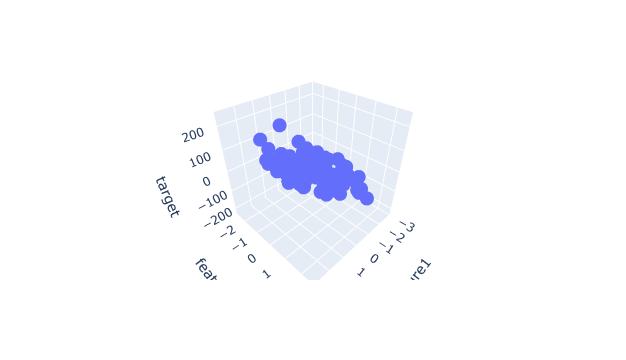

In [35]:
fig=px.scatter_3d(df,x='feature1',y='feature2',z='target')
fig.show()

In [36]:
from sklearn.model_selection import train_test_split

In [37]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=3)

In [38]:
from sklearn.linear_model import LinearRegression

In [39]:
lr=LinearRegression()

In [40]:
lr.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [41]:
y_pred=lr.predict(X_test)

In [42]:
print("MAE",mean_absolute_error(y_test,y_pred))
print("MSE",mean_squared_error(y_test,y_pred))
print("R2 score",r2_score(y_test,y_pred))

MAE 49.63420895432263
MSE 3549.5346676778054
R2 score 0.678403172172203


In [45]:
x = np.linspace(-5, 5, 10)
y = np.linspace(-5, 5, 10)
xGrid, yGrid = np.meshgrid(y, x)

z_final = lr.predict(X).reshape(10,10)

z = z_final

final = np.vstack((xGrid.ravel().reshape(1,100),yGrid.ravel().reshape(1,100))).T

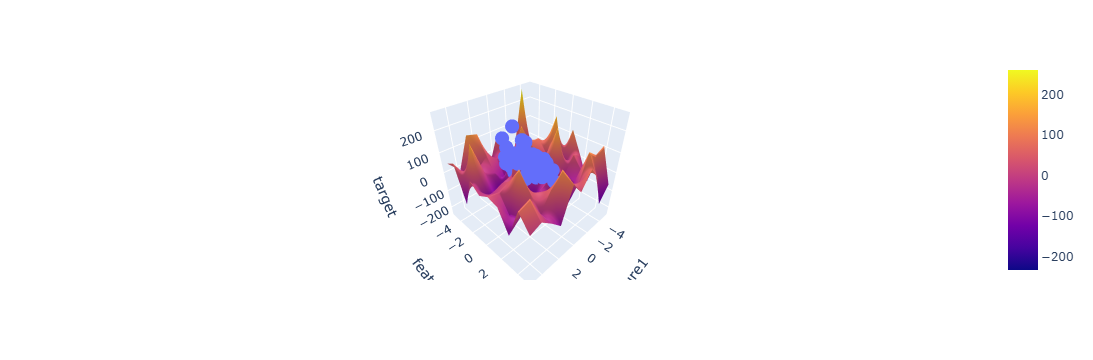

In [46]:
fig = px.scatter_3d(df, x='feature1', y='feature2', z='target')

fig.add_trace(go.Surface(x = x, y = y, z =z ))

fig.show()

In [47]:
lr.coef_

array([76.24697359, 38.62809453])

In [48]:
lr.intercept_

np.float64(-6.655973098077039)

# KNN

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv("E:\data.csv")

In [4]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [5]:
df.drop(columns=['id','Unnamed: 32'],inplace=True)
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [6]:
df.shape

(569, 31)

In [9]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.iloc[:,1:], df.iloc[:,0],test_size=0.2, random_state=2)

In [10]:
X_train.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
560,14.05,27.15,91.38,600.4,0.09929,0.11260,0.04462,0.04304,0.1537,0.06171,...,15.30,33.17,100.20,706.7,0.1241,0.22640,0.1326,0.10480,0.2250,0.08321
428,11.13,16.62,70.47,381.1,0.08151,0.03834,0.01369,0.01370,0.1511,0.06148,...,11.68,20.29,74.35,421.1,0.1030,0.06219,0.0458,0.04044,0.2383,0.07083
198,19.18,22.49,127.50,1148.0,0.08523,0.14280,0.11140,0.06772,0.1767,0.05529,...,23.36,32.06,166.40,1688.0,0.1322,0.56010,0.3865,0.17080,0.3193,0.09221
203,13.81,23.75,91.56,597.8,0.13230,0.17680,0.15580,0.09176,0.2251,0.07421,...,19.20,41.85,128.50,1153.0,0.2226,0.52090,0.4646,0.20130,0.4432,0.10860
41,10.95,21.35,71.90,371.1,0.12270,0.12180,0.10440,0.05669,0.1895,0.06870,...,12.84,35.34,87.22,514.0,0.1909,0.26980,0.4023,0.14240,0.2964,0.09606


In [11]:
X_train.shape

(455, 30)

In [12]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [13]:
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [15]:
X_train

array([[-0.01330339,  1.7757658 , -0.01491962, ..., -0.13236958,
        -1.08014517, -0.03527943],
       [-0.8448276 , -0.6284278 , -0.87702746, ..., -1.11552632,
        -0.85773964, -0.72098905],
       [ 1.44755936,  0.71180168,  1.47428816, ...,  0.87583964,
         0.4967602 ,  0.46321706],
       ...,
       [-0.46608541, -1.49375484, -0.53234924, ..., -1.32388956,
        -1.02997851, -0.75145272],
       [-0.50025764, -1.62161319, -0.527814  , ..., -0.0987626 ,
         0.35796577, -0.43906159],
       [ 0.96060511,  1.21181916,  1.00427242, ...,  0.8956983 ,
        -1.23064515,  0.50697397]], shape=(455, 30))

In [19]:
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier()

In [20]:
knn.fit(X_train,y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [21]:
from sklearn.metrics import accuracy_score
y_pred=knn.predict(X_test)
accuracy_score(y_test,y_pred)

0.9736842105263158

In [22]:
scores=[]

for i in range(1,16):
    knn=KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train,y_train)
    y_pred=knn.predict(X_test)

    scores.append(accuracy_score(y_test,y_pred))

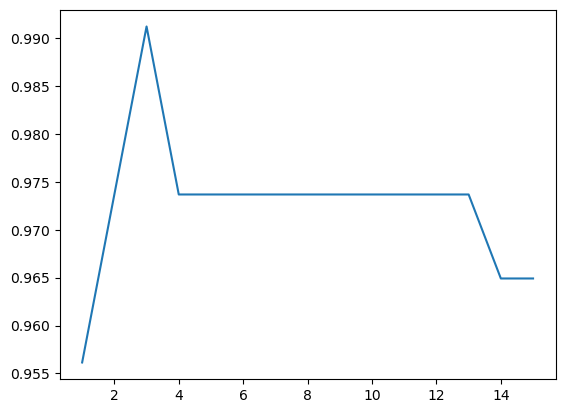

In [23]:
plt.plot(range(1,16),scores)

In [25]:
from sklearn import neighbors,datasets
from sklearn.preprocessing import StandardScaler
from ipywidgets import interact,fixed

def load_data():
    cancer=datasets.load_breast_cancer()
    return cancer

def plot_decision_boundaries(n_neighbours,data,lables):
    h=0.02
    cmap_light=ListedColormap(['orange','blue'])
    cmap_bold=ListedColormap(['darkorange','darkblue'])

    clf=neighbors.KNeighborsClassifier(n_neighbours)
    clf.fit(data,labels)

    x_min, x_max = data[:, 0].min() - 1, data[:, 0].max() + 1
    y_min, y_max = data[:, 1].min() - 1, data[:, 1].max() + 1

    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])

    Z = Z.reshape(xx.shape)
    plt.figure(figsize=(8, 6))
    plt.pcolormesh(xx, yy, Z, cmap=cmap_light)

    plt.scatter(data[:, 0], data[:, 1], c=labels, cmap=cmap_bold, edgecolor='k', s=20)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.title(f'2-Class classification (k = {n_neighbors})')
    plt.show()

cancer = load_data()

# Use only the first two features and standardize them.
X = StandardScaler().fit_transform(cancer.data[:, :2])
    